In [1]:
file = open("students.csv", "w", encoding="utf-8")
file.write("name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed\n")
file.write("Alice,88,92,76,80,95,92,4.5,1\n")
file.write("Bob,42,55,48,50,60,65,1.2,0\n")
file.write("Charlie,75,70,80,68,88,85,3.0,1\n")
file.write("Diana,95,98,91,89,97,98,6.0,1\n")
file.write("Eve,38,42,50,45,55,58,0.8,0\n")
file.write("Frank,60,65,72,58,70,78,2.5,1\n")
file.write("Grace,55,48,44,52,62,60,1.5,0\n")
file.write("Henry,82,79,85,77,90,88,4.0,1\n")
file.write("Iris,70,74,68,65,78,80,3.5,1\n")
file.write("Jack,30,35,40,28,45,50,0.5,0\n")
file.write("Karen,65,60,70,62,75,72,2.8,1\n")
file.write("Liam,48,52,44,55,58,62,1.8,0\n")
file.write("Mia,91,94,88,92,96,95,5.5,1\n")
file.write("Noah,58,62,55,60,68,70,2.0,0\n")
file.write("Olivia,78,75,82,70,85,84,3.8,1\n")
file.close()
print("students.csv created!")

students.csv created!


# ***Task 1 — Data Exploration with Pandas***

In [2]:
import pandas as pd

#Loading CSV
df = pd.read_csv("students.csv")

#1:- First 5 Rows print
print("First 5 rows: ")
print(df.head())

#2:- Shape and Data types
print(f"\nShape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

#3: Summary statistics
print("\nSummary Statistics:")
print(df.describe())

#4: Pass/Fail count
print("\nPass/Fail Count:")
print(df['passed'].value_counts())

#5: Subject columns define karo
subject_cols = ['math', 'science', 'english', 'history', 'pe']


#Average of passed students
print("\nAverage scores - Passing students:")
print(df[df['passed'] == 1][subject_cols].mean())

#Average of failed students
print("\nAverage scores - Failing students:")
print(df[df['passed'] == 0][subject_cols].mean())

#6:- Find Topper
#Find average of each student for all subjects
df['temp_avg'] = df[subject_cols].mean(axis=1)

#Highest Average student
topper_index = df['temp_avg'].idxmax()
topper = df.loc[topper_index]
print(f"\nTopper: {topper['name']} with average {round(topper['temp_avg'], 2)}")
df = df.drop(columns=['temp_avg'])


First 5 rows: 
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    science    english   

# ***Task2:- Matplotilb(5plots)***

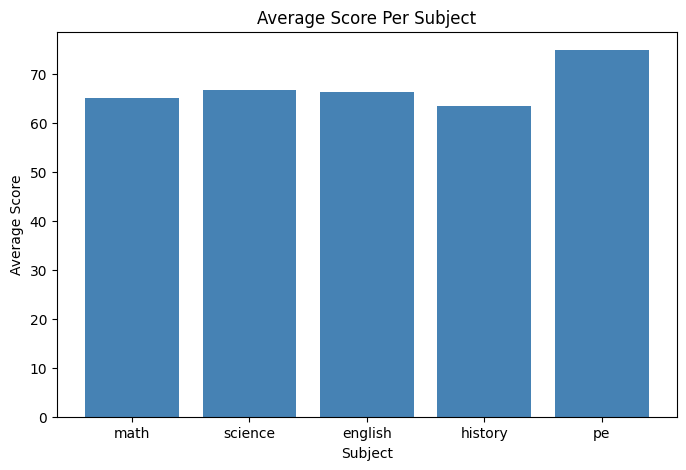

Plot 1 saved!


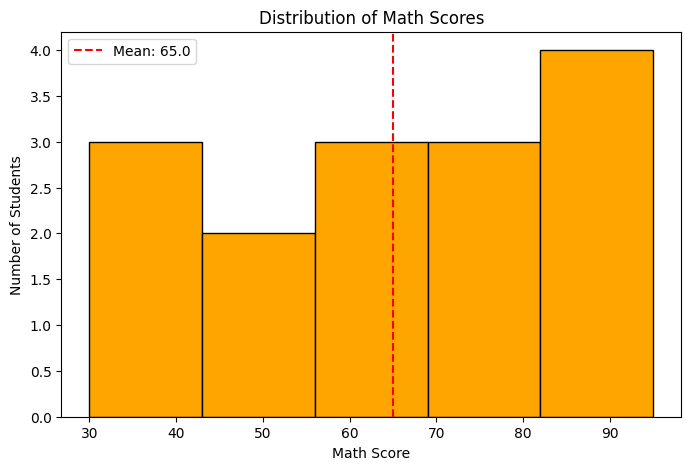

Plot 2 saved!


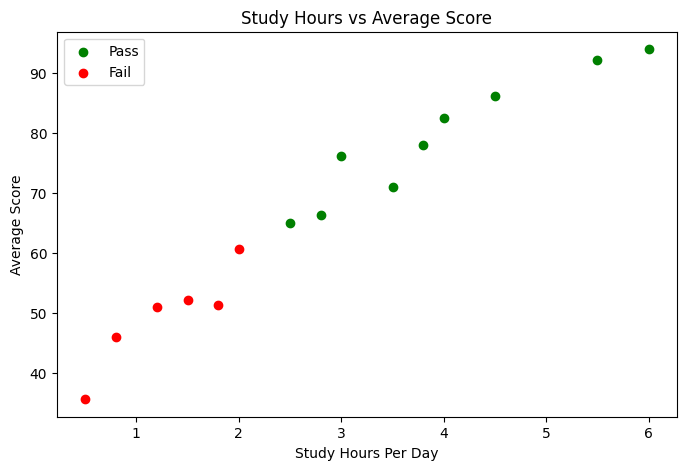

Plot 3 saved!


/tmp/ipykernel_14292/1166670523.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


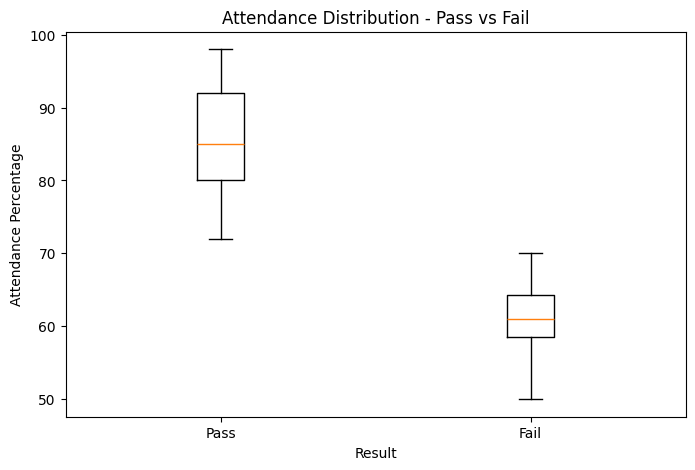

Plot 4 saved!


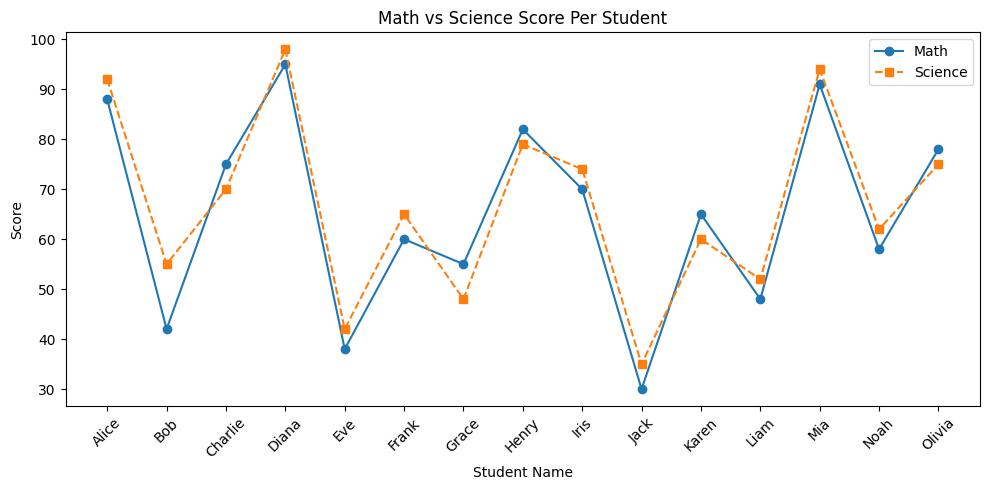

Plot 5 saved!


In [3]:
import matplotlib.pyplot as plt

#Adding column of average_score
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


#====PLOT 1:- Bar Chart=====
#Average of each subject across all students
subject_averages = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_cols, subject_averages, color='steelblue')
plt.title("Average Score Per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()
print("Plot 1 saved!")

#====PLOT 2:- HISTOGRAM====
#Distribution of maths's score
mean_math = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='orange', edgecolor='black')
plt.axvline(mean_math, color='red', linestyle='dashed', label=f"Mean: {round(mean_math, 2)}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()
print("Plot 2 saved!")

#====PLOT 3:-SCATTER PLOT====
#Study hours vs avg_score -Pass/Fail in different colours
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()
print("Plot 3 saved!")

#====PLOT 4:- BOX PLOT====
#Attendance pass vs fail
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution - Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_boxplot.png")
plt.show()
print("Plot 4 saved!")

#====PLOT 5:- LINE PLOT====
#Score of maths and science of each student
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', linestyle='-')
plt.plot(df['name'], df['science'], marker='s', label='Science', linestyle='--')
plt.title("Math vs Science Score Per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()
print("Plot 5 saved!")


# ***Task 3 — Data Visualization with Seaborn***

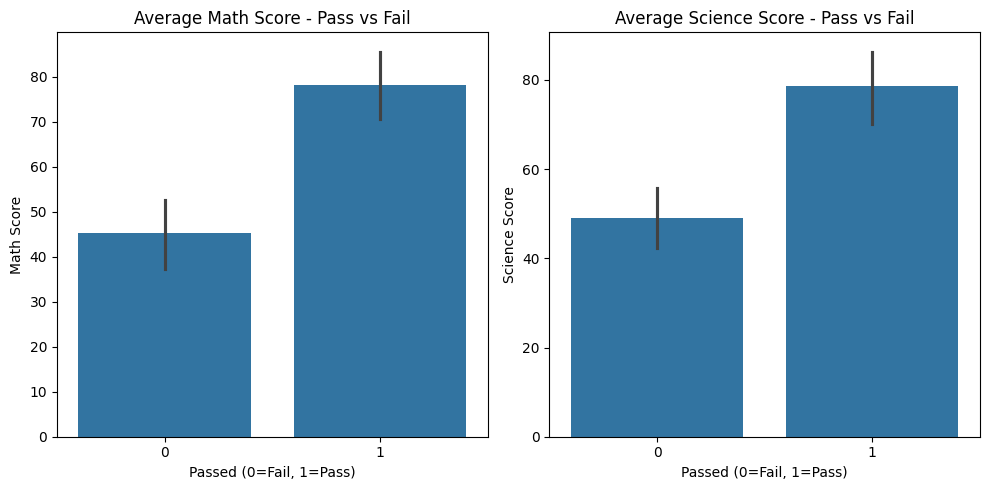

Plot 1 saved!


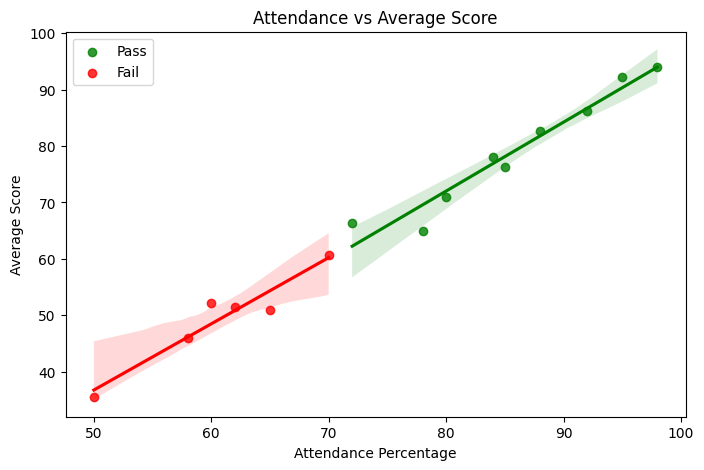

Plot 2 saved!


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

#====SEABORN BAR PLOT====
#Average of maths and science-pass vs fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Math bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score - Pass vs Fail")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Science bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score - Pass vs Fail")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()
print("Plot 1 saved!")


#====SEABORN SCATTER+REGRESSION====
#Attendeance vs avg_score - pass and fail wil be two different lines
plt.figure(figsize=(8, 5))

# Pass students
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', label='Pass', color='green')

# Fail students
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', label='Fail', color='red')

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()
print("Plot 2 saved!")



# ***SEABORN VS MATPLOTLIB***

Seaborn provides more visually appealing outputs with less code, as it has built-in styling.

Matplotlib offers greater control and customization, but it requires writing more code.


Adding a regression line is very straightforward in Seaborn, whereas in Matplotlib it needs to be done manually.

# ***Task 4 — Machine Learning with scikit-learn***

Training samples: 12
Testing samples: 3

Training Accuracy: 100.0%
Test Accuracy: 100.0%

Prediction Results:
--------------------------------------------------
Jack       | Actual: Fail  | Predicted: Fail  | ✅ Correct
Liam       | Actual: Fail  | Predicted: Fail  | ✅ Correct
Alice      | Actual: Pass  | Predicted: Pass  | ✅ Correct

Feature Importance:
----------------------------------------
english                   : 0.8125
attendance_pct            : 0.5219
study_hours_per_day       : 0.4844
pe                        : 0.475
math                      : 0.4379
science                   : 0.323
history                   : 0.2629


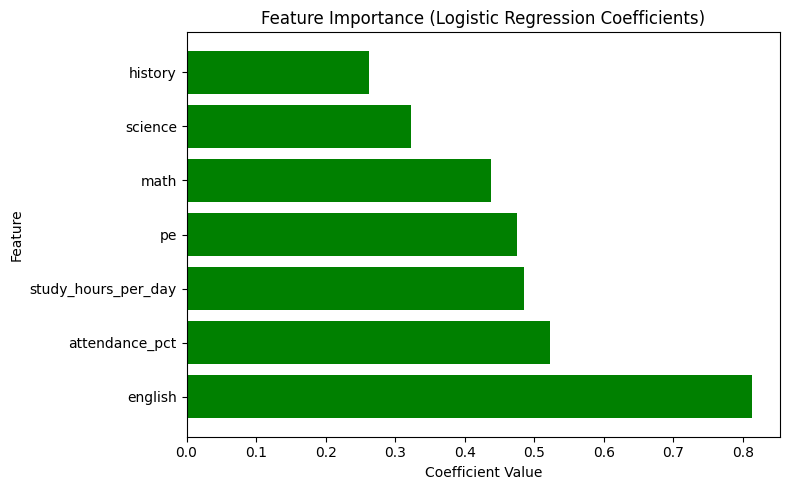

Plot 1 saved!

New Student Prediction: Pass
Probability — Fail: 9.2% | Pass: 90.8%


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

#1:- Data Preparation
#Split features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


#2:- Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_accuracy = model.score(X_train_scaled, y_train)
print(f"\nTraining Accuracy: {round(train_accuracy * 100, 2)}%")


#3:- Model Evaulate
# Test predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {round(test_accuracy * 100, 2)}%")

#print each test for student's name+actual+predicted
print("\nPrediction Results:")
print("-" * 50)
student_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(student_names, y_test, y_pred):
  result = "✅ Correct" if actual == predicted else "❌ Wrong"
  actual_label = "Pass" if actual == 1 else "Fail"
  pred_label = "Pass" if predicted == 1 else "Fail"
  print(f"{name:<10} | Actual: {actual_label:<5} | Predicted: {pred_label:<5} | {result}")


#4:- Feature Importance

#Model coefficient
coefficients = model.coef_[0]

#Pair Feature name and coefficient
feature_importance = list(zip(feature_cols, coefficients))

#Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
print("-" * 40)
for feature, coef in feature_importance:
 print(f"{feature:<25} : {round(coef, 4)}")

#Horizontal Bar Chart

features = [f[0] for f in feature_importance]
coefs = [f[1] for f in feature_importance]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(8, 5))
plt.barh(features, coefs, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()
print("Plot 1 saved!")



#5:- Bonus:- New student prediction
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

#Scale
new_scaled = scaler.transform(new_student)

#Prediction
prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"
print(f"\nNew Student Prediction: {result}")
print(f"Probability — Fail: {round(probability[0][0]*100, 2)}% | Pass: {round(probability[0][1]*100, 2)}%")
